In [23]:
from pathlib import Path
import os
import json
import hashlib
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from PIL import Image

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Python:", os.sys.version)
print("TensorFlow:", tf.__version__)
print("Working directory:", os.getcwd())

Python: 3.12.0 (tags/v3.12.0:0fb18b0, Oct  2 2023, 13:03:39) [MSC v.1935 64 bit (AMD64)]
TensorFlow: 2.20.0
Working directory: d:\downloads\misleading-health-infographic-detection\notebooks


In [24]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "outputs").exists():
    for parent in Path.cwd().parents:
        if (parent / "outputs").exists():
            PROJECT_ROOT = parent
            break

OUTPUTS_DIR = PROJECT_ROOT / "outputs"

OUTPUTS10_DIR = OUTPUTS_DIR / "outputs10"
PHASE10_DIR = OUTPUTS_DIR / "phase10"
PHASE11_DIR = OUTPUTS_DIR / "phase11"

AUDIT_DIR = PHASE11_DIR / "audit"
DATASET_DIR = PHASE11_DIR / "datasets"
METRICS_DIR = PHASE11_DIR / "metrics"
PLOTS_DIR = PHASE11_DIR / "plots"
ERROR_DIR = PHASE11_DIR / "error_analysis"
EXPLAIN_DIR = PHASE11_DIR / "explainability"
CHECKPOINT_DIR = PHASE11_DIR / "checkpoints"
REPORT_DIR = PHASE11_DIR / "reports"

for directory in [
    AUDIT_DIR,
    DATASET_DIR,
    METRICS_DIR,
    PLOTS_DIR,
    ERROR_DIR,
    EXPLAIN_DIR,
    CHECKPOINT_DIR,
    REPORT_DIR
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )

print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUTPUTS10_DIR:", OUTPUTS10_DIR)
print("PHASE10_DIR:", PHASE10_DIR)
print("PHASE11_DIR:", PHASE11_DIR)

PROJECT_ROOT: d:\downloads\misleading-health-infographic-detection
OUTPUTS10_DIR: d:\downloads\misleading-health-infographic-detection\outputs\outputs10
PHASE10_DIR: d:\downloads\misleading-health-infographic-detection\outputs\phase10
PHASE11_DIR: d:\downloads\misleading-health-infographic-detection\outputs\phase11


In [25]:
paths_to_check = {
    "record_level_dataset":
        OUTPUTS10_DIR / "record_level_dataset" / "record_level_dataset.csv",

    "outputs10 final_dataset":
        OUTPUTS10_DIR / "final_dataset",

    "outputs10 leakage checkpoint":
        OUTPUTS10_DIR / "leakage_safe_checkpoints",

    "phase10 images":
        PHASE10_DIR / "images",

    "phase10 clean_images":
        PHASE10_DIR / "clean_images",

    "phase10 clean_images_v2":
        PHASE10_DIR / "clean_images_v2",
}

for name, path in paths_to_check.items():
    print(
        f"{name:35} -> {path.exists()}"
    )

record_level_dataset                -> True
outputs10 final_dataset             -> True
outputs10 leakage checkpoint        -> True
phase10 images                      -> True
phase10 clean_images                -> True
phase10 clean_images_v2             -> True


In [26]:
RECORD_PATH = (
    OUTPUTS10_DIR
    / "record_level_dataset"
    / "record_level_dataset.csv"
)

record_df = pd.read_csv(RECORD_PATH)

print("Shape:", record_df.shape)

print("\nColumns:")
print(record_df.columns.tolist())

display(record_df.head())

Shape: (5776, 10)

Columns:
['record_key', 'subset', 'record_id', 'label', 'source', 'is_english', 'text', 'split', 'image_path', 'local_path']


,record_key,subset,record_id,label,source,is_english,text,split,image_path,local_path
0,MM-COVID19_0,MM-COVID19,0,1,MM-COVID19,True,Coronavirus Is a Breeding Ground for Conspirac...,test,human_data/MM-COVID19/0_1.jpg,c:\Users\aditi\Desktop\DL PROJECT\misleading-h...
1,MM-COVID19_1,MM-COVID19,1,1,MM-COVID19,True,COVID-19 and PPE: Some of Us Will Die\nWhat yo...,train,human_data/MM-COVID19/1_10.jpg,c:\Users\aditi\Desktop\DL PROJECT\misleading-h...
2,MM-COVID19_10,MM-COVID19,10,1,MM-COVID19,True,Commentary: Lessons on COVID-19 From Low-Incom...,train,human_data/MM-COVID19/10_10.jpg,c:\Users\aditi\Desktop\DL PROJECT\misleading-h...
3,MM-COVID19_11,MM-COVID19,11,1,MM-COVID19,True,COMMENTARY: COVID-19 Diary Day 1: Something Wi...,test,human_data/MM-COVID19/11_10.jpg,c:\Users\aditi\Desktop\DL PROJECT\misleading-h...
4,MM-COVID19_12,MM-COVID19,12,1,MM-COVID19,True,Coronavirus Social: Mourning Colleagues Lost t...,test,human_data/MM-COVID19/12_10.jpg,c:\Users\aditi\Desktop\DL PROJECT\misleading-h...


In [27]:
print("Labels:")
print(record_df["label"].value_counts())

print("\nSources:")
print(record_df["source"].value_counts())

print("\nOriginal splits:")
print(record_df["split"].value_counts())

print("\nSplit × Label:")
print(
    record_df
    .groupby(["split", "label"])
    .size()
)

Labels:
label
1    4650
0    1126
Name: count, dtype: int64

Sources:
source
MMCoVar       1598
Med-MMHL      1416
ReCOVery      1383
MM-COVID19    1379
Name: count, dtype: int64

Original splits:
split
train         4043
test           867
validation     866
Name: count, dtype: int64

Split × Label:
split       label
test        0         169
            1         698
train       0         788
            1        3255
validation  0         169
            1         697
dtype: int64


In [28]:
PHASE10_IMAGE_DIR = (
    PHASE10_DIR / "images"
)

image_files = [
    p
    for p in PHASE10_IMAGE_DIR.rglob("*")
    if p.is_file()
]

print(
    "Phase 10 image files:",
    len(image_files)
)

for p in image_files[:20]:
    print(p)

Phase 10 image files: 16394
d:\downloads\misleading-health-infographic-detection\outputs\phase10\images\Med-MMHL-merge\0_0.jpg
d:\downloads\misleading-health-infographic-detection\outputs\phase10\images\Med-MMHL-merge\0_0_1.jpg
d:\downloads\misleading-health-infographic-detection\outputs\phase10\images\Med-MMHL-merge\0_1.jpg
d:\downloads\misleading-health-infographic-detection\outputs\phase10\images\Med-MMHL-merge\1001_0.jpg
d:\downloads\misleading-health-infographic-detection\outputs\phase10\images\Med-MMHL-merge\1001_1.jpg
d:\downloads\misleading-health-infographic-detection\outputs\phase10\images\Med-MMHL-merge\1001_2.jpg
d:\downloads\misleading-health-infographic-detection\outputs\phase10\images\Med-MMHL-merge\1001_3.jpg
d:\downloads\misleading-health-infographic-detection\outputs\phase10\images\Med-MMHL-merge\1001_4.jpg
d:\downloads\misleading-health-infographic-detection\outputs\phase10\images\Med-MMHL-merge\1001_6.jpg
d:\downloads\misleading-health-infographic-detection\outputs\

In [29]:
from collections import defaultdict

image_lookup = {}

for path in PHASE10_IMAGE_DIR.rglob("*"):

    if not path.is_file():
        continue

    if path.suffix.lower() not in {
        ".jpg",
        ".jpeg",
        ".png",
        ".bmp",
        ".gif"
    }:
        continue

    image_lookup[
        path.name.lower()
    ] = path

print(
    "Indexed local images:",
    len(image_lookup)
)

Indexed local images: 15262


In [30]:
def resolve_image(row):

    image_path = str(
        row["image_path"]
    )

    filename = Path(
        image_path
    ).name.lower()

    # First try filename
    if filename in image_lookup:
        return str(
            image_lookup[filename]
        )

    return None


record_df["resolved_image_path"] = (
    record_df.apply(
        resolve_image,
        axis=1
    )
)

print(
    "Resolved:",
    record_df["resolved_image_path"]
    .notna()
    .sum()
)

print(
    "Missing:",
    record_df["resolved_image_path"]
    .isna()
    .sum()
)

Resolved: 5776
Missing: 0


In [31]:
def check_image(path):

    try:

        with Image.open(path) as img:
            img.verify()

        return True

    except Exception:
        return False


record_df["valid_image"] = (
    record_df[
        "resolved_image_path"
    ].apply(check_image)
)

print(
    record_df["valid_image"]
    .value_counts()
)

valid_image
True    5776
Name: count, dtype: int64


In [32]:
invalid_images = record_df[
    ~record_df["valid_image"]
]

if len(invalid_images) > 0:

    invalid_images.to_csv(
        AUDIT_DIR / "invalid_images.csv",
        index=False
    )

    raise RuntimeError(
        f"{len(invalid_images)} invalid images found."
    )

record_df.drop(
    columns=["valid_image"],
    inplace=True
)

print("All images are valid.")

All images are valid.


In [33]:
def sha256_file(
    path,
    chunk_size=1024 * 1024
):

    sha256 = hashlib.sha256()

    with open(path, "rb") as f:

        while True:

            chunk = f.read(
                chunk_size
            )

            if not chunk:
                break

            sha256.update(
                chunk
            )

    return sha256.hexdigest()

In [34]:
record_df["image_hash"] = (
    record_df[
        "resolved_image_path"
    ].apply(
        sha256_file
    )
)

print(
    "Missing image hashes:",
    record_df[
        "image_hash"
    ].isna().sum()
)

print(
    "Unique images:",
    record_df[
        "image_hash"
    ].nunique()
)

Missing image hashes: 0
Unique images: 4162


In [35]:
def normalize_text(text):

    if pd.isna(text):
        return ""

    return (
        str(text)
        .strip()
        .lower()
    )


def sha256_text(text):

    return hashlib.sha256(
        text.encode("utf-8")
    ).hexdigest()


record_df["text_key"] = (
    record_df["text"]
    .apply(normalize_text)
)

record_df["text_hash"] = (
    record_df["text_key"]
    .apply(sha256_text)
)

print(
    "Unique text groups:",
    record_df[
        "text_hash"
    ].nunique()
)

Unique text groups: 5718


In [36]:
image_counts = (
    record_df
    .groupby("image_hash")
    .size()
    .reset_index(
        name="record_count"
    )
)

duplicate_images = (
    image_counts[
        image_counts["record_count"] > 1
    ]
)

print(
    "Unique image hashes:",
    len(image_counts)
)

print(
    "Duplicate image groups:",
    len(duplicate_images)
)

print(
    "Records in duplicate image groups:",
    duplicate_images[
        "record_count"
    ].sum()
)

Unique image hashes: 4162
Duplicate image groups: 1164
Records in duplicate image groups: 2778


In [37]:
duplicate_images.to_csv(
    AUDIT_DIR
    / "duplicate_image_groups.csv",
    index=False
)

In [38]:
image_label_counts = (
    record_df
    .groupby("image_hash")["label"]
    .nunique()
)

conflicting_image_hashes = set(
    image_label_counts[
        image_label_counts > 1
    ].index
)

print(
    "Conflicting image groups:",
    len(conflicting_image_hashes)
)

Conflicting image groups: 62


In [39]:
text_label_counts = (
    record_df
    .groupby("text_hash")["label"]
    .nunique()
)

conflicting_text_hashes = set(
    text_label_counts[
        text_label_counts > 1
    ].index
)

print(
    "Conflicting text groups:",
    len(conflicting_text_hashes)
)

Conflicting text groups: 0


In [40]:
record_df[
    record_df["image_hash"]
    .isin(conflicting_image_hashes)
].to_csv(
    AUDIT_DIR
    / "conflicting_image_records.csv",
    index=False
)

record_df[
    record_df["text_hash"]
    .isin(conflicting_text_hashes)
].to_csv(
    AUDIT_DIR
    / "conflicting_text_records.csv",
    index=False
)

In [41]:
conflict_mask = (
    record_df[
        "image_hash"
    ].isin(
        conflicting_image_hashes
    )
    |
    record_df[
        "text_hash"
    ].isin(
        conflicting_text_hashes
    )
)

excluded_conflicts = (
    record_df[
        conflict_mask
    ].copy()
)

safe_df = (
    record_df[
        ~conflict_mask
    ].copy()
)

print(
    "Original records:",
    len(record_df)
)

print(
    "Excluded:",
    len(excluded_conflicts)
)

print(
    "Safe records:",
    len(safe_df)
)

Original records: 5776
Excluded: 154
Safe records: 5622


In [42]:
excluded_conflicts.to_csv(
    AUDIT_DIR
    / "excluded_conflicting_records.csv",
    index=False
)

In [43]:
parent = list(
    range(len(safe_df))
)

rank = [
    0
] * len(safe_df)


def find(x):

    while parent[x] != x:

        parent[x] = parent[
            parent[x]
        ]

        x = parent[x]

    return x


def union(a, b):

    root_a = find(a)
    root_b = find(b)

    if root_a == root_b:
        return

    if rank[root_a] < rank[root_b]:

        parent[root_a] = root_b

    elif rank[root_a] > rank[root_b]:

        parent[root_b] = root_a

    else:

        parent[root_b] = root_a

        rank[root_a] += 1

In [44]:
image_owner = {}
text_owner = {}

for idx, (_, row) in enumerate(
    safe_df.iterrows()
):

    image_hash = row[
        "image_hash"
    ]

    text_hash = row[
        "text_hash"
    ]

    if image_hash in image_owner:

        union(
            idx,
            image_owner[
                image_hash
            ]
        )

    else:

        image_owner[
            image_hash
        ] = idx


    if text_hash in text_owner:

        union(
            idx,
            text_owner[
                text_hash
            ]
        )

    else:

        text_owner[
            text_hash
        ] = idx

In [45]:
safe_df["group_id"] = [
    find(i)
    for i in range(
        len(safe_df)
    )
]

safe_df["group_id"] = (
    safe_df[
        "group_id"
    ].astype(str)
)

print(
    "Leakage groups:",
    safe_df[
        "group_id"
    ].nunique()
)

Leakage groups: 4055


In [46]:
audit_summary = {

    "original_records":
        int(len(record_df)),

    "excluded_conflicting_records":
        int(len(excluded_conflicts)),

    "safe_records":
        int(len(safe_df)),

    "unique_image_hashes":
        int(
            safe_df[
                "image_hash"
            ].nunique()
        ),

    "unique_text_hashes":
        int(
            safe_df[
                "text_hash"
            ].nunique()
        ),

    "unique_leakage_groups":
        int(
            safe_df[
                "group_id"
            ].nunique()
        ),

    "conflicting_image_groups":
        int(
            len(
                conflicting_image_hashes
            )
        ),

    "conflicting_text_groups":
        int(
            len(
                conflicting_text_hashes
            )
        )
}

with open(
    AUDIT_DIR
    / "pre_split_audit_summary.json",
    "w"
) as f:

    json.dump(
        audit_summary,
        f,
        indent=4
    )

print(
    json.dumps(
        audit_summary,
        indent=4
    )
)

{
    "original_records": 5776,
    "excluded_conflicting_records": 154,
    "safe_records": 5622,
    "unique_image_hashes": 4100,
    "unique_text_hashes": 5565,
    "unique_leakage_groups": 4055,
    "conflicting_image_groups": 62,
    "conflicting_text_groups": 0
}


In [47]:
sgkf = StratifiedGroupKFold(
    n_splits=7,
    shuffle=True,
    random_state=SEED
)

X = safe_df.index.to_numpy()

y = (
    safe_df["label"]
    .astype(int)
    .to_numpy()
)

groups = (
    safe_df["group_id"]
    .to_numpy()
)

fold_indices = []

for fold, (
    train_indices,
    holdout_indices
) in enumerate(
    sgkf.split(
        X,
        y,
        groups
    )
):

    fold_indices.append(
        holdout_indices
    )

    print(
        f"Fold {fold}:",
        len(holdout_indices)
    )

Fold 0: 803
Fold 1: 803
Fold 2: 803
Fold 3: 803
Fold 4: 803
Fold 5: 803
Fold 6: 804


In [48]:
test_idx = fold_indices[0]

val_idx = fold_indices[1]

holdout = (
    set(test_idx)
    |
    set(val_idx)
)

train_idx = np.array([
    i
    for i in range(
        len(safe_df)
    )
    if i not in holdout
])

train_df = (
    safe_df
    .iloc[train_idx]
    .copy()
)

val_df = (
    safe_df
    .iloc[val_idx]
    .copy()
)

test_df = (
    safe_df
    .iloc[test_idx]
    .copy()
)

print(
    "Train:",
    len(train_df)
)

print(
    "Validation:",
    len(val_df)
)

print(
    "Test:",
    len(test_df)
)

Train: 4016
Validation: 803
Test: 803


In [49]:
print(
    pd.DataFrame({

        "train":
            train_df[
                "label"
            ].value_counts()
            .sort_index(),

        "validation":
            val_df[
                "label"
            ].value_counts()
            .sort_index(),

        "test":
            test_df[
                "label"
            ].value_counts()
            .sort_index()

    })
)

       train  validation  test
label                         
0        758         151   151
1       3258         652   652


In [50]:
def overlap(
    df1,
    df2,
    column
):

    return len(
        set(
            df1[column]
        )
        &
        set(
            df2[column]
        )
    )


leakage_checks = {

    "train_val_image":
        overlap(
            train_df,
            val_df,
            "image_hash"
        ),

    "train_test_image":
        overlap(
            train_df,
            test_df,
            "image_hash"
        ),

    "val_test_image":
        overlap(
            val_df,
            test_df,
            "image_hash"
        ),

    "train_val_text":
        overlap(
            train_df,
            val_df,
            "text_hash"
        ),

    "train_test_text":
        overlap(
            train_df,
            test_df,
            "text_hash"
        ),

    "val_test_text":
        overlap(
            val_df,
            test_df,
            "text_hash"
        ),

    "train_val_group":
        overlap(
            train_df,
            val_df,
            "group_id"
        ),

    "train_test_group":
        overlap(
            train_df,
            test_df,
            "group_id"
        ),

    "val_test_group":
        overlap(
            val_df,
            test_df,
            "group_id"
        )
}

print(
    json.dumps(
        leakage_checks,
        indent=4
    )
)

{
    "train_val_image": 0,
    "train_test_image": 0,
    "val_test_image": 0,
    "train_val_text": 0,
    "train_test_text": 0,
    "val_test_text": 0,
    "train_val_group": 0,
    "train_test_group": 0,
    "val_test_group": 0
}


In [51]:
train_df.to_csv(
    DATASET_DIR
    / "final_train.csv",
    index=False
)

val_df.to_csv(
    DATASET_DIR
    / "final_validation.csv",
    index=False
)

test_df.to_csv(
    DATASET_DIR
    / "final_test.csv",
    index=False
)

In [52]:
with open(
    AUDIT_DIR
    / "final_split_audit.json",
    "w"
) as f:

    json.dump(
        {
            "train":
                len(train_df),

            "validation":
                len(val_df),

            "test":
                len(test_df),

            "leakage_checks":
                leakage_checks
        },
        f,
        indent=4
    )

In [53]:
IMG_SIZE = (
    224,
    224
)

BATCH_SIZE = 16

AUTOTUNE = (
    tf.data.AUTOTUNE
)

In [54]:
def create_multimodal_dataset(
    dataframe,
    shuffle=False
):

    paths = (
        dataframe[
            "resolved_image_path"
        ]
        .astype(str)
        .values
    )

    texts = (
        dataframe[
            "text"
        ]
        .fillna("")
        .astype(str)
        .values
    )

    labels = (
        dataframe[
            "label"
        ]
        .astype(np.float32)
        .values
    )

    ds = tf.data.Dataset.from_tensor_slices(
        (
            paths,
            texts,
            labels
        )
    )

    if shuffle:

        ds = ds.shuffle(
            buffer_size=min(
                len(dataframe),
                1000
            ),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    def process(
        path,
        text,
        label
    ):

        image = tf.io.read_file(
            path
        )

        image = tf.io.decode_image(
            image,
            channels=3,
            expand_animations=False
        )

        image.set_shape(
            [None, None, 3]
        )

        image = tf.image.resize(
            image,
            IMG_SIZE
        )

        image = tf.cast(
            image,
            tf.float32
        )

        return {
            "image": image,
            "text": text
        }, label

    ds = ds.map(
        process,
        num_parallel_calls=AUTOTUNE
    )

    ds = ds.batch(
        BATCH_SIZE
    )

    ds = ds.prefetch(
        AUTOTUNE
    )

    return ds

In [55]:
train_ds = create_multimodal_dataset(
    train_df,
    shuffle=True
)

val_ds = create_multimodal_dataset(
    val_df
)

test_ds = create_multimodal_dataset(
    test_df
)

In [56]:
x_batch, y_batch = next(
    iter(train_ds)
)

print(
    "Image:",
    x_batch["image"].shape
)

print(
    "Text:",
    x_batch["text"].shape
)

print(
    "Labels:",
    y_batch.shape
)

Image: (16, 224, 224, 3)
Text: (16,)
Labels: (16,)


In [57]:
MAX_TOKENS = 20000

SEQUENCE_LENGTH = 300

In [58]:
text_vectorizer = (
    tf.keras.layers.TextVectorization(
        max_tokens=MAX_TOKENS,
        output_mode="int",
        output_sequence_length=SEQUENCE_LENGTH,
        standardize="lower_and_strip_punctuation"
    )
)

text_vectorizer.adapt(
    train_df[
        "text"
    ]
    .fillna("")
    .astype(str)
    .values
)

print(
    "Vocabulary size:",
    len(
        text_vectorizer
        .get_vocabulary()
    )
)

Vocabulary size: 20000


In [59]:
from tensorflow.keras import (
    layers,
    Model
)

from tensorflow.keras.applications import (
    EfficientNetB0
)

In [60]:
image_input = layers.Input(
    shape=(224, 224, 3),
    name="image"
)

image_base = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

image_base.trainable = False

image_features = image_base(
    image_input,
    training=False
)

image_features = (
    layers.GlobalAveragePooling2D()
    (image_features)
)

image_features = layers.Dense(
    128,
    activation="relu"
)(image_features)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


In [61]:
text_input = layers.Input(
    shape=(),
    dtype=tf.string,
    name="text"
)

text_tokens = (
    text_vectorizer(
        text_input
    )
)

text_features = layers.Embedding(
    input_dim=MAX_TOKENS,
    output_dim=128,
    mask_zero=True
)(text_tokens)

text_features = layers.Bidirectional(
    layers.LSTM(64)
)(text_features)

text_features = layers.Dense(
    128,
    activation="relu"
)(text_features)

In [62]:
combined = layers.Concatenate()([
    image_features,
    text_features
])

combined = layers.Dense(
    128,
    activation="relu"
)(combined)

combined = layers.Dropout(
    0.4
)(combined)

combined = layers.Dense(
    64,
    activation="relu"
)(combined)

combined = layers.Dropout(
    0.3
)(combined)

output = layers.Dense(
    1,
    activation="sigmoid",
    name="output"
)(combined)

In [63]:
model = Model(
    inputs=[
        image_input,
        text_input
    ],
    outputs=output
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),

    loss="binary_crossentropy",

    metrics=[
        "accuracy",

        tf.keras.metrics.Precision(
            name="precision"
        ),

        tf.keras.metrics.Recall(
            name="recall"
        ),

        tf.keras.metrics.AUC(
            name="auc"
        )
    ]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text (InputLayer)   │ (None)            │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization  │ (None, 300)       │          0 │ text[0][0]        │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 7, 7,      │  4,049,571 │ image[0][0]       │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 300, 128)  │  2,560,000 │ text_vectorizati… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 300)       │          0 │ text_vectorizati… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ efficientnetb0[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 128)       │     98,816 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │    163,968 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     16,512 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256)       │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     32,896 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         65 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,930,084 (26.44 MB)

 Trainable params: 2,880,513 (10.99 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [64]:
classes = np.unique(
    train_df[
        "label"
    ].astype(int)
)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df[
        "label"
    ].astype(int)
)

class_weights = dict(
    zip(
        classes,
        weights
    )
)

print(
    "Class weights:",
    class_weights
)

Class weights: {np.int64(0): np.float64(2.649076517150396), np.int64(1): np.float64(0.616329036218539)}


In [65]:
BEST_MODEL_PATH = (
    CHECKPOINT_DIR
    / "best_multimodal_model.keras"
)

callbacks = [

    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(
            BEST_MODEL_PATH
        ),
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1
    )
]

In [67]:
# ============================================================
# FIX: Use weights-only checkpoint to avoid Windows Unicode
# serialization problem with the .keras full-model checkpoint
# ============================================================

WEIGHTS_PATH = (
    CHECKPOINT_DIR /
    "best_multimodal_model.weights.h5"
)

weights_callbacks = [

    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(WEIGHTS_PATH),
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1
    )
]

print("New checkpoint path:")
print(WEIGHTS_PATH)

New checkpoint path:
d:\downloads\misleading-health-infographic-detection\outputs\phase11\checkpoints\best_multimodal_model.weights.h5


In [68]:
EPOCHS = 10

history_remaining = model.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=0,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=weights_callbacks
)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 765ms/step - accuracy: 0.7037 - auc: 0.7637 - loss: 0.5850 - precision: 0.9064 - recall: 0.7078
Epoch 1: val_auc improved from None to 0.84158, saving model to d:\downloads\misleading-health-infographic-detection\outputs\phase11\checkpoints\best_multimodal_model.weights.h5

Epoch 1: finished saving model to d:\downloads\misleading-health-infographic-detection\outputs\phase11\checkpoints\best_multimodal_model.weights.h5
251/251 ━━━━━━━━━━━━━━━━━━━━ 230s 909ms/step - accuracy: 0.7037 - auc: 0.7637 - loss: 0.5850 - precision: 0.9064 - recall: 0.7078 - val_accuracy: 0.8331 - val_auc: 0.8416 - val_loss: 0.4433 - val_precision: 0.9218 - val_recall: 0.8681 - learning_rate: 1.0000e-04
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 725ms/step - accuracy: 0.8840 - auc: 0.9497 - loss: 0.2958 - precision: 0.9716 - recall: 0.8828
Epoch 2: val_auc improved from 0.84158 to 0.96987, saving model to d:\downloads\misleading-health-infographic-detection\outputs\phas

In [69]:
if WEIGHTS_PATH.exists():

    model.load_weights(
        WEIGHTS_PATH
    )

    print(
        "Best validation-AUC weights loaded successfully."
    )

else:

    print(
        "Weights checkpoint not found."
    )

Best validation-AUC weights loaded successfully.


In [72]:
history_df = pd.DataFrame(
    history_remaining.history
)

display(history_df)

,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall,learning_rate
0,0.703685,0.763653,0.585012,0.906447,0.707796,0.833126,0.841583,0.443264,0.921824,0.868098,0.0001
1,0.883964,0.949708,0.295849,0.971622,0.882750,0.925280,0.969874,0.206815,0.975884,0.930982,0.0001
2,0.969123,0.993863,0.097857,0.991531,0.970227,0.914072,0.970056,0.229855,0.978654,0.914110,0.0001
3,0.990538,0.999250,0.032567,0.998761,0.989564,0.931507,0.964709,0.201699,0.947526,0.969325,0.0001
4,0.996514,0.999883,0.015347,0.999692,0.996010,0.930261,0.946131,0.251507,0.939528,0.976994,0.0001
5,0.997510,0.999980,0.008265,0.999385,0.997545,0.932752,0.932866,0.318307,0.943620,0.975460,0.0001


In [73]:
history_df.to_csv(
    METRICS_DIR / "training_history.csv",
    index=False
)

print(
    "Training history saved to:",
    METRICS_DIR / "training_history.csv"
)

Training history saved to: d:\downloads\misleading-health-infographic-detection\outputs\phase11\metrics\training_history.csv


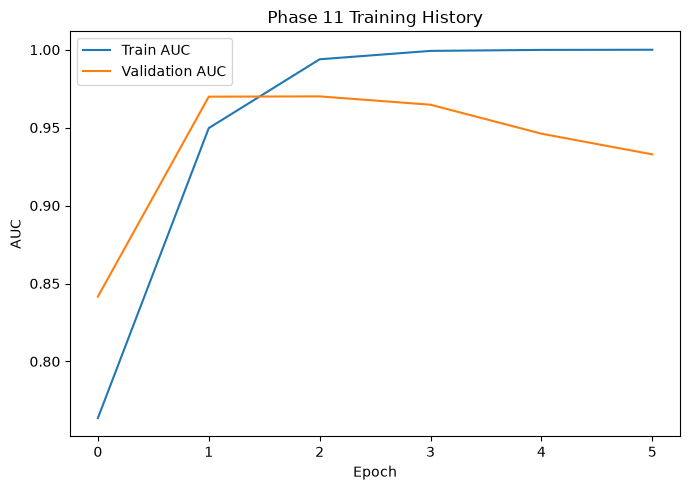

In [74]:
plt.figure(figsize=(7, 5))

plt.plot(
    history_remaining.history["auc"],
    label="Train AUC"
)

plt.plot(
    history_remaining.history["val_auc"],
    label="Validation AUC"
)

plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("Phase 11 Training History")
plt.legend()

plt.tight_layout()

plt.savefig(
    PLOTS_DIR / "training_auc.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

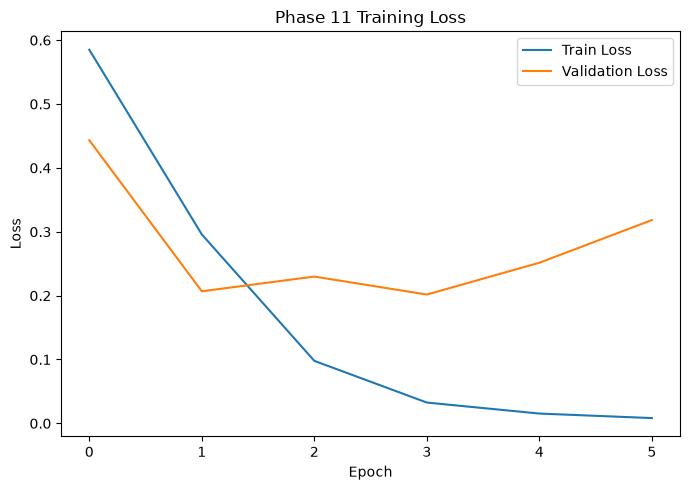

In [75]:
plt.figure(figsize=(7, 5))

plt.plot(
    history_remaining.history["loss"],
    label="Train Loss"
)

plt.plot(
    history_remaining.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Phase 11 Training Loss")
plt.legend()

plt.tight_layout()

plt.savefig(
    PLOTS_DIR / "training_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [76]:
if WEIGHTS_PATH.exists():

    model.load_weights(
        WEIGHTS_PATH
    )

    print(
        "Best validation-AUC weights loaded successfully."
    )

else:

    print(
        "Weights checkpoint not found."
    )

Best validation-AUC weights loaded successfully.


In [77]:
val_probabilities = (
    model.predict(
        val_ds,
        verbose=1
    )
    .ravel()
)

val_labels = (
    val_df["label"]
    .astype(int)
    .to_numpy()
)

print(
    "Validation predictions:",
    len(val_probabilities)
)

print(
    "Validation labels:",
    len(val_labels)
)

51/51 ━━━━━━━━━━━━━━━━━━━━ 40s 701ms/step
Validation predictions: 803
Validation labels: 803


In [78]:
threshold_results = []

for threshold in np.arange(
    0.10,
    0.91,
    0.01
):

    predictions = (
        val_probabilities >= threshold
    ).astype(int)

    threshold_results.append({

        "threshold":
            float(threshold),

        "accuracy":
            accuracy_score(
                val_labels,
                predictions
            ),

        "precision":
            precision_score(
                val_labels,
                predictions,
                zero_division=0
            ),

        "recall":
            recall_score(
                val_labels,
                predictions,
                zero_division=0
            ),

        "f1":
            f1_score(
                val_labels,
                predictions,
                zero_division=0
            )
    })

threshold_df = pd.DataFrame(
    threshold_results
)

best_threshold_row = threshold_df.loc[
    threshold_df["f1"].idxmax()
]

BEST_THRESHOLD = float(
    best_threshold_row["threshold"]
)

print(
    "Best validation threshold:",
    BEST_THRESHOLD
)

display(
    best_threshold_row.to_frame().T
)

Best validation threshold: 0.21999999999999995


,threshold,accuracy,precision,recall,f1
12,0.22,0.931507,0.96136,0.953988,0.95766


In [79]:
threshold_df.to_csv(
    METRICS_DIR /
    "validation_threshold_analysis.csv",
    index=False
)

In [80]:
test_probabilities = (
    model.predict(
        test_ds,
        verbose=1
    )
    .ravel()
)

test_labels = (
    test_df["label"]
    .astype(int)
    .to_numpy()
)

test_predictions = (
    test_probabilities >= BEST_THRESHOLD
).astype(int)

51/51 ━━━━━━━━━━━━━━━━━━━━ 34s 653ms/step


In [81]:
threshold_df.to_csv(
    METRICS_DIR /
    "validation_threshold_analysis.csv",
    index=False
)

In [82]:
final_metrics = {

    "threshold":
        BEST_THRESHOLD,

    "accuracy":
        accuracy_score(
            test_labels,
            test_predictions
        ),

    "precision":
        precision_score(
            test_labels,
            test_predictions,
            zero_division=0
        ),

    "recall":
        recall_score(
            test_labels,
            test_predictions,
            zero_division=0
        ),

    "f1_score":
        f1_score(
            test_labels,
            test_predictions,
            zero_division=0
        ),

    "roc_auc":
        roc_auc_score(
            test_labels,
            test_probabilities
        ),

    "pr_auc":
        average_precision_score(
            test_labels,
            test_probabilities
        )
}

print(
    json.dumps(
        final_metrics,
        indent=4
    )
)

{
    "threshold": 0.21999999999999995,
    "accuracy": 0.8991282689912827,
    "precision": 0.9538950715421304,
    "recall": 0.9202453987730062,
    "f1_score": 0.936768149882904,
    "roc_auc": 0.9345975703896315,
    "pr_auc": 0.9822670079517324
}


In [83]:
with open(
    METRICS_DIR /
    "final_test_metrics.json",
    "w"
) as f:

    json.dump(
        final_metrics,
        f,
        indent=4
    )

In [84]:
# ============================================================
# CELL 58 — FINAL CLASSIFICATION REPORT
# ============================================================

classification_rep = classification_report(
    test_labels,
    test_predictions,
    target_names=[
        "Non-Misleading",
        "Misleading"
    ],
    zero_division=0
)

print(classification_rep)

classification_report_path = (
    METRICS_DIR /
    "classification_report.txt"
)

with open(
    classification_report_path,
    "w",
    encoding="utf-8"
) as f:
    f.write(classification_rep)

print(
    "\nClassification report saved to:"
)
print(classification_report_path)

                precision    recall  f1-score   support

Non-Misleading       0.70      0.81      0.75       151
    Misleading       0.95      0.92      0.94       652

      accuracy                           0.90       803
     macro avg       0.83      0.86      0.84       803
  weighted avg       0.91      0.90      0.90       803


Classification report saved to:
d:\downloads\misleading-health-infographic-detection\outputs\phase11\metrics\classification_report.txt


In [85]:
# ============================================================
# CELL 59 — CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    test_labels,
    test_predictions
)

print("Confusion Matrix:")
print(cm)

cm_df = pd.DataFrame(
    cm,
    index=[
        "Actual_Non-Misleading",
        "Actual_Misleading"
    ],
    columns=[
        "Predicted_Non-Misleading",
        "Predicted_Misleading"
    ]
)

display(cm_df)

cm_df.to_csv(
    METRICS_DIR /
    "confusion_matrix.csv"
)

Confusion Matrix:
[[122  29]
 [ 52 600]]


,Predicted_Non-Misleading,Predicted_Misleading
Actual_Non-Misleading,122,29
Actual_Misleading,52,600


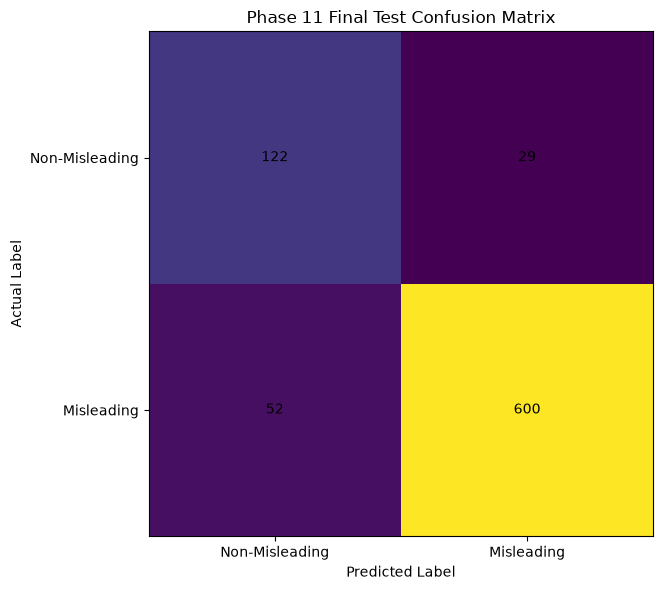

Saved: d:\downloads\misleading-health-infographic-detection\outputs\phase11\plots\confusion_matrix.png


In [86]:
# ============================================================
# CELL 60 — CONFUSION MATRIX PLOT
# ============================================================

plt.figure(
    figsize=(7, 6)
)

plt.imshow(cm)

plt.xticks(
    [0, 1],
    [
        "Non-Misleading",
        "Misleading"
    ]
)

plt.yticks(
    [0, 1],
    [
        "Non-Misleading",
        "Misleading"
    ]
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "Actual Label"
)

plt.title(
    "Phase 11 Final Test Confusion Matrix"
)

for i in range(cm.shape[0]):

    for j in range(cm.shape[1]):

        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center"
        )

plt.tight_layout()

cm_plot_path = (
    PLOTS_DIR /
    "confusion_matrix.png"
)

plt.savefig(
    cm_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    cm_plot_path
)

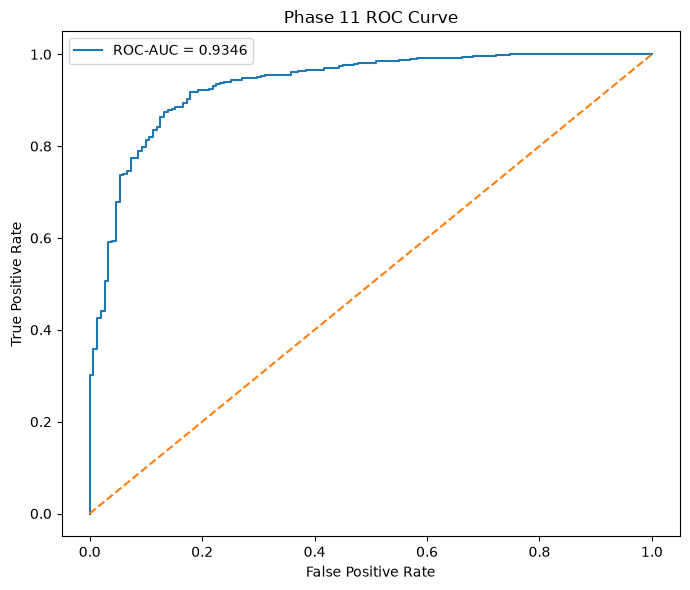

ROC-AUC: 0.9345975703896315
Saved: d:\downloads\misleading-health-infographic-detection\outputs\phase11\plots\roc_curve.png


In [87]:
# ============================================================
# CELL 61 — ROC CURVE
# ============================================================

fpr, tpr, roc_thresholds = roc_curve(
    test_labels,
    test_probabilities
)

roc_auc = roc_auc_score(
    test_labels,
    test_probabilities
)

plt.figure(
    figsize=(7, 6)
)

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "Phase 11 ROC Curve"
)

plt.legend()

plt.tight_layout()

roc_plot_path = (
    PLOTS_DIR /
    "roc_curve.png"
)

plt.savefig(
    roc_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "ROC-AUC:",
    roc_auc
)

print(
    "Saved:",
    roc_plot_path
)

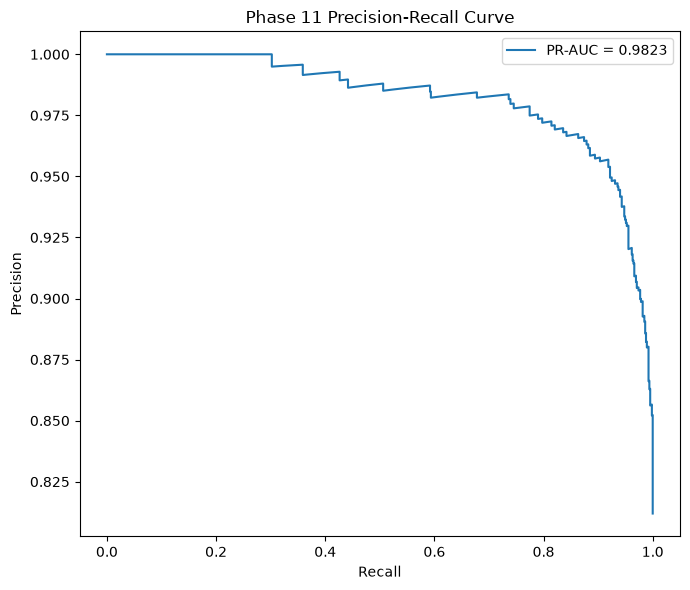

PR-AUC: 0.9822670079517324
Saved: d:\downloads\misleading-health-infographic-detection\outputs\phase11\plots\precision_recall_curve.png


In [88]:
# ============================================================
# CELL 62 — PRECISION-RECALL CURVE
# ============================================================

pr_precision, pr_recall, pr_thresholds = (
    precision_recall_curve(
        test_labels,
        test_probabilities
    )
)

pr_auc = average_precision_score(
    test_labels,
    test_probabilities
)

plt.figure(
    figsize=(7, 6)
)

plt.plot(
    pr_recall,
    pr_precision,
    label=f"PR-AUC = {pr_auc:.4f}"
)

plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Phase 11 Precision-Recall Curve"
)

plt.legend()

plt.tight_layout()

pr_plot_path = (
    PLOTS_DIR /
    "precision_recall_curve.png"
)

plt.savefig(
    pr_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "PR-AUC:",
    pr_auc
)

print(
    "Saved:",
    pr_plot_path
)

In [89]:
# ============================================================
# CELL 63 — SAVE RECORD-LEVEL TEST PREDICTIONS
# ============================================================

prediction_df = test_df.copy()

prediction_df[
    "predicted_probability"
] = test_probabilities

prediction_df[
    "predicted_label"
] = test_predictions

prediction_df[
    "correct"
] = (
    prediction_df["label"].astype(int)
    ==
    prediction_df["predicted_label"]
)

prediction_df[
    "prediction_confidence"
] = np.where(
    prediction_df["predicted_label"] == 1,
    prediction_df["predicted_probability"],
    1 - prediction_df["predicted_probability"]
)

prediction_df[
    "uncertainty"
] = (
    prediction_df["predicted_probability"] - 0.5
).abs()

prediction_path = (
    ERROR_DIR /
    "test_predictions.csv"
)

prediction_df.to_csv(
    prediction_path,
    index=False
)

print(
    "Saved test predictions to:"
)

print(prediction_path)

display(
    prediction_df[
        [
            "record_key",
            "source",
            "label",
            "predicted_probability",
            "predicted_label",
            "correct"
        ]
    ].head(10)
)

Saved test predictions to:
d:\downloads\misleading-health-infographic-detection\outputs\phase11\error_analysis\test_predictions.csv


,record_key,source,label,predicted_probability,predicted_label,correct
9,MM-COVID19_17,MM-COVID19,1,0.152799,0,False
10,MM-COVID19_18,MM-COVID19,1,0.994132,1,True
14,MM-COVID19_21,MM-COVID19,1,0.022168,0,False
28,MM-COVID19_3309,MM-COVID19,1,0.268918,1,True
31,MM-COVID19_3312,MM-COVID19,1,0.998012,1,True
40,MM-COVID19_3344,MM-COVID19,0,0.392112,1,False
48,MM-COVID19_34,MM-COVID19,1,0.459435,1,True
49,MM-COVID19_3411,MM-COVID19,0,0.096776,0,True
53,MM-COVID19_3423,MM-COVID19,0,0.060768,0,True
56,MM-COVID19_3439,MM-COVID19,0,0.192580,0,True


In [90]:
# ============================================================
# CELL 64 — ERROR CLASSIFICATION
# ============================================================

prediction_df[
    "error_type"
] = np.select(

    [
        (
            (prediction_df["label"].astype(int) == 0)
            &
            (prediction_df["predicted_label"] == 1)
        ),

        (
            (prediction_df["label"].astype(int) == 1)
            &
            (prediction_df["predicted_label"] == 0)
        )
    ],

    [
        "False Positive",
        "False Negative"
    ],

    default="Correct"
)

all_errors = prediction_df[
    prediction_df["error_type"] != "Correct"
].copy()

false_positives = prediction_df[
    prediction_df["error_type"] == "False Positive"
].copy()

false_negatives = prediction_df[
    prediction_df["error_type"] == "False Negative"
].copy()

print(
    "Total test records:",
    len(prediction_df)
)

print(
    "Total errors:",
    len(all_errors)
)

print(
    "False positives:",
    len(false_positives)
)

print(
    "False negatives:",
    len(false_negatives)
)

Total test records: 803
Total errors: 81
False positives: 29
False negatives: 52


In [91]:
# ============================================================
# CELL 65 — SAVE ERROR ANALYSIS
# ============================================================

all_errors.to_csv(
    ERROR_DIR /
    "all_errors.csv",
    index=False
)

false_positives.to_csv(
    ERROR_DIR /
    "false_positives.csv",
    index=False
)

false_negatives.to_csv(
    ERROR_DIR /
    "false_negatives.csv",
    index=False
)

print(
    "Error-analysis files saved."
)

Error-analysis files saved.


In [92]:
# ============================================================
# CELL 67 — SOURCE-WISE TEST PERFORMANCE
# ============================================================

source_results = []

for source in sorted(
    test_df["source"]
    .dropna()
    .unique()
):

    mask = (
        test_df["source"].to_numpy()
        == source
    )

    source_labels = (
        test_labels[mask]
    )

    source_probabilities = (
        test_probabilities[mask]
    )

    source_predictions = (
        test_predictions[mask]
    )

    result = {

        "source":
            source,

        "samples":
            int(len(source_labels)),

        "accuracy":
            accuracy_score(
                source_labels,
                source_predictions
            ),

        "precision":
            precision_score(
                source_labels,
                source_predictions,
                zero_division=0
            ),

        "recall":
            recall_score(
                source_labels,
                source_predictions,
                zero_division=0
            ),

        "f1":
            f1_score(
                source_labels,
                source_predictions,
                zero_division=0
            )
    }

    if len(
        np.unique(source_labels)
    ) == 2:

        result["roc_auc"] = (
            roc_auc_score(
                source_labels,
                source_probabilities
            )
        )

        result["pr_auc"] = (
            average_precision_score(
                source_labels,
                source_probabilities
            )
        )

    else:

        result["roc_auc"] = np.nan
        result["pr_auc"] = np.nan

    source_results.append(
        result
    )

source_metrics = pd.DataFrame(
    source_results
)

display(
    source_metrics
)

,source,samples,accuracy,precision,recall,f1,roc_auc,pr_auc
0,MM-COVID19,195,0.810256,0.872000,0.838462,0.854902,0.869349,0.926168
1,MMCoVar,220,0.922727,0.994536,0.919192,0.955381,0.975207,0.997277
2,Med-MMHL,194,0.969072,0.967320,0.993289,0.980132,0.988963,0.996106
3,ReCOVery,194,0.891753,0.958333,0.920000,0.938776,0.868571,0.981757


In [93]:
# ============================================================
# CELL 68 — SAVE SOURCE-WISE METRICS
# ============================================================

source_metrics.to_csv(
    METRICS_DIR /
    "source_wise_metrics.csv",
    index=False
)

print(
    "Saved source-wise metrics."
)

Saved source-wise metrics.


In [94]:
# ============================================================
# CELL 69 — ERROR RATE BY SOURCE
# ============================================================

error_by_source = (
    prediction_df
    .assign(
        is_error=
        prediction_df["correct"] == False
    )
    .groupby("source")
    .agg(
        total_samples=(
            "record_key",
            "count"
        ),
        errors=(
            "is_error",
            "sum"
        )
    )
    .reset_index()
)

error_by_source[
    "error_rate"
] = (
    error_by_source["errors"]
    /
    error_by_source["total_samples"]
)

display(
    error_by_source
)

error_by_source.to_csv(
    ERROR_DIR /
    "errors_by_source.csv",
    index=False
)

,source,total_samples,errors,error_rate
0,MM-COVID19,195,37,0.189744
1,MMCoVar,220,17,0.077273
2,Med-MMHL,194,6,0.030928
3,ReCOVery,194,21,0.108247


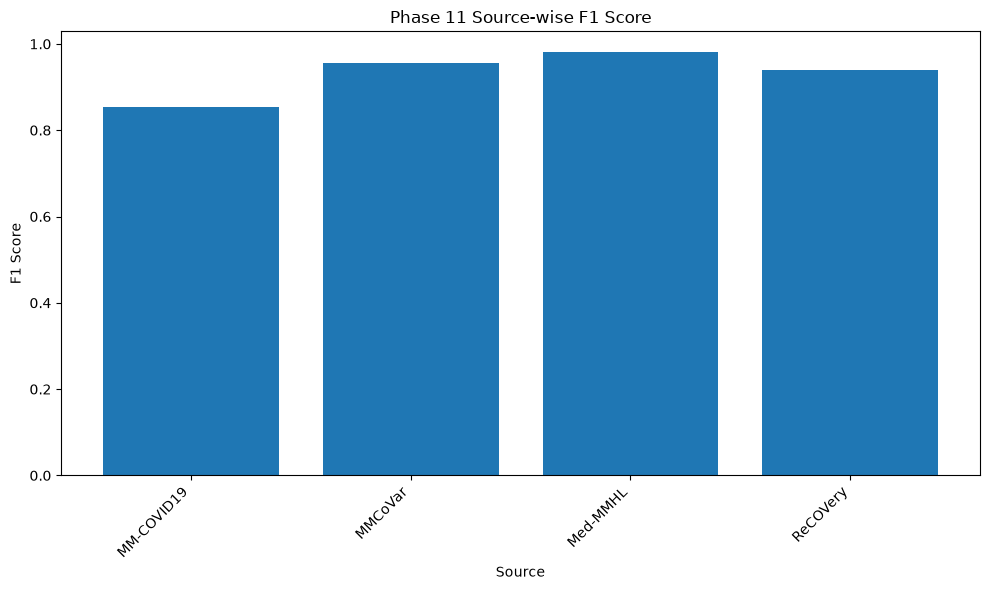

Saved: d:\downloads\misleading-health-infographic-detection\outputs\phase11\plots\source_wise_f1.png


In [95]:
# ============================================================
# CELL 70 — SOURCE-WISE F1
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.bar(
    source_metrics["source"].astype(str),
    source_metrics["f1"]
)

plt.xlabel(
    "Source"
)

plt.ylabel(
    "F1 Score"
)

plt.title(
    "Phase 11 Source-wise F1 Score"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

source_f1_plot = (
    PLOTS_DIR /
    "source_wise_f1.png"
)

plt.savefig(
    source_f1_plot,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    source_f1_plot
)

In [96]:
# ============================================================
# CELL 71 — FINAL SUMMARY
# ============================================================

final_summary = {

    "phase":
        "Phase 11",

    "seed":
        SEED,

    "dataset": {

        "original_records":
            int(len(record_df)),

        "safe_records":
            int(len(safe_df)),

        "excluded_conflicting_records":
            int(len(excluded_conflicts)),

        "train_records":
            int(len(train_df)),

        "validation_records":
            int(len(val_df)),

        "test_records":
            int(len(test_df))
    },

    "model": {

        "image_encoder":
            "EfficientNetB0",

        "text_encoder":
            "TextVectorization + Embedding + Bidirectional LSTM",

        "fusion":
            "Concatenation + Dense layers",

        "image_size":
            [224, 224],

        "max_tokens":
            int(MAX_TOKENS),

        "sequence_length":
            int(SEQUENCE_LENGTH)
    },

    "threshold": {
        "validation_selected":
            float(BEST_THRESHOLD)
    },

    "test_metrics": {

        "accuracy":
            float(final_metrics["accuracy"]),

        "precision":
            float(final_metrics["precision"]),

        "recall":
            float(final_metrics["recall"]),

        "f1_score":
            float(final_metrics["f1_score"]),

        "roc_auc":
            float(final_metrics["roc_auc"]),

        "pr_auc":
            float(final_metrics["pr_auc"])
    },

    "errors": {

        "total":
            int(len(all_errors)),

        "false_positives":
            int(len(false_positives)),

        "false_negatives":
            int(len(false_negatives))
    }
}

print(
    json.dumps(
        final_summary,
        indent=4
    )
)

{
    "phase": "Phase 11",
    "seed": 42,
    "dataset": {
        "original_records": 5776,
        "safe_records": 5622,
        "excluded_conflicting_records": 154,
        "train_records": 4016,
        "validation_records": 803,
        "test_records": 803
    },
    "model": {
        "image_encoder": "EfficientNetB0",
        "text_encoder": "TextVectorization + Embedding + Bidirectional LSTM",
        "fusion": "Concatenation + Dense layers",
        "image_size": [
            224,
            224
        ],
        "max_tokens": 20000,
        "sequence_length": 300
    },
    "threshold": {
        "validation_selected": 0.21999999999999995
    },
    "test_metrics": {
        "accuracy": 0.8991282689912827,
        "precision": 0.9538950715421304,
        "recall": 0.9202453987730062,
        "f1_score": 0.936768149882904,
        "roc_auc": 0.9345975703896315,
        "pr_auc": 0.9822670079517324
    },
    "errors": {
        "total": 81,
        "false_positives": 29,
 

In [97]:
# ============================================================
# CELL 72 — SAVE FINAL SUMMARY
# ============================================================

summary_path = (
    REPORT_DIR /
    "phase11_final_summary.json"
)

with open(
    summary_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        final_summary,
        f,
        indent=4
    )

print(
    "Saved:",
    summary_path
)

Saved: d:\downloads\misleading-health-infographic-detection\outputs\phase11\reports\phase11_final_summary.json


In [98]:
# ============================================================
# CELL 73 — FINAL PHASE 11 REPORT
# ============================================================

report_lines = []

report_lines.append(
    "# Phase 11 Final Evaluation Report"
)

report_lines.append("")

report_lines.append(
    "## 1. Dataset"
)

report_lines.append(
    f"- Original records: {len(record_df)}"
)

report_lines.append(
    f"- Excluded conflicting records: "
    f"{len(excluded_conflicts)}"
)

report_lines.append(
    f"- Final safe records: {len(safe_df)}"
)

report_lines.append(
    f"- Training records: {len(train_df)}"
)

report_lines.append(
    f"- Validation records: {len(val_df)}"
)

report_lines.append(
    f"- Test records: {len(test_df)}"
)

report_lines.append("")

report_lines.append(
    "## 2. Leakage Audit"
)

for key, value in leakage_checks.items():

    report_lines.append(
        f"- {key}: {value}"
    )

report_lines.append("")

report_lines.append(
    "## 3. Model Architecture"
)

report_lines.append(
    "- Image encoder: EfficientNetB0"
)

report_lines.append(
    "- Text encoder: TextVectorization + "
    "Embedding + Bidirectional LSTM"
)

report_lines.append(
    "- Fusion: Concatenation followed by "
    "fully connected layers"
)

report_lines.append(
    "- Image size: 224 × 224"
)

report_lines.append("")

report_lines.append(
    "## 4. Threshold Selection"
)

report_lines.append(
    f"- Validation-selected threshold: "
    f"{BEST_THRESHOLD:.4f}"
)

report_lines.append("")

report_lines.append(
    "## 5. Final Test Metrics"
)

report_lines.append(
    f"- Accuracy: "
    f"{final_metrics['accuracy']:.4f}"
)

report_lines.append(
    f"- Precision: "
    f"{final_metrics['precision']:.4f}"
)

report_lines.append(
    f"- Recall: "
    f"{final_metrics['recall']:.4f}"
)

report_lines.append(
    f"- F1 Score: "
    f"{final_metrics['f1_score']:.4f}"
)

report_lines.append(
    f"- ROC-AUC: "
    f"{final_metrics['roc_auc']:.4f}"
)

report_lines.append(
    f"- PR-AUC: "
    f"{final_metrics['pr_auc']:.4f}"
)

report_lines.append("")

report_lines.append(
    "## 6. Error Analysis"
)

report_lines.append(
    f"- Total errors: {len(all_errors)}"
)

report_lines.append(
    f"- False positives: {len(false_positives)}"
)

report_lines.append(
    f"- False negatives: {len(false_negatives)}"
)

report_lines.append("")

report_lines.append(
    "## 7. Generated Artifacts"
)

report_lines.extend([
    "- Final test predictions",
    "- Classification report",
    "- Confusion matrix",
    "- ROC curve",
    "- Precision-recall curve",
    "- Source-wise metrics",
    "- Error analysis",
    "- Uncertain predictions",
    "- Training history",
    "- Final metrics JSON",
    "- Final Phase 11 summary"
])

report_lines.append("")

report_lines.append(
    "## 8. Leakage Verification"
)

if all(
    value == 0
    for value in leakage_checks.values()
):

    report_lines.append(
        "All image, text, and group overlap checks "
        "between train, validation, and test sets "
        "are zero."
    )

else:

    report_lines.append(
        "WARNING: One or more leakage checks "
        "are non-zero. Review final_split_audit.json."
    )

report_text = "\n".join(
    report_lines
)

report_path = (
    REPORT_DIR /
    "phase11_final_report.md"
)

with open(
    report_path,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        report_text
    )

print(
    "Final report saved to:"
)

print(report_path)

print("\n")
print(report_text)

Final report saved to:
d:\downloads\misleading-health-infographic-detection\outputs\phase11\reports\phase11_final_report.md


# Phase 11 Final Evaluation Report

## 1. Dataset
- Original records: 5776
- Excluded conflicting records: 154
- Final safe records: 5622
- Training records: 4016
- Validation records: 803
- Test records: 803

## 2. Leakage Audit
- train_val_image: 0
- train_test_image: 0
- val_test_image: 0
- train_val_text: 0
- train_test_text: 0
- val_test_text: 0
- train_val_group: 0
- train_test_group: 0
- val_test_group: 0

## 3. Model Architecture
- Image encoder: EfficientNetB0
- Text encoder: TextVectorization + Embedding + Bidirectional LSTM
- Fusion: Concatenation followed by fully connected layers
- Image size: 224 × 224

## 4. Threshold Selection
- Validation-selected threshold: 0.2200

## 5. Final Test Metrics
- Accuracy: 0.8991
- Precision: 0.9539
- Recall: 0.9202
- F1 Score: 0.9368
- ROC-AUC: 0.9346
- PR-AUC: 0.9823

## 6. Error Analysis
- Total errors: 81
- Fals

In [99]:
# ============================================================
# CELL 74 — PHASE 11 COMPLETION CHECK
# ============================================================

expected_files = [

    CHECKPOINT_DIR /
    "best_multimodal_model.weights.h5",

    DATASET_DIR /
    "final_train.csv",

    DATASET_DIR /
    "final_validation.csv",

    DATASET_DIR /
    "final_test.csv",

    METRICS_DIR /
    "training_history.csv",

    METRICS_DIR /
    "validation_threshold_analysis.csv",

    METRICS_DIR /
    "final_test_metrics.json",

    METRICS_DIR /
    "classification_report.txt",

    METRICS_DIR /
    "confusion_matrix.csv",

    METRICS_DIR /
    "source_wise_metrics.csv",

    PLOTS_DIR /
    "training_auc.png",

    PLOTS_DIR /
    "training_loss.png",

    PLOTS_DIR /
    "confusion_matrix.png",

    PLOTS_DIR /
    "roc_curve.png",

    PLOTS_DIR /
    "precision_recall_curve.png",

    ERROR_DIR /
    "test_predictions.csv",

    ERROR_DIR /
    "all_errors.csv",

    ERROR_DIR /
    "false_positives.csv",

    ERROR_DIR /
    "false_negatives.csv",

    ERROR_DIR /
    "most_uncertain_predictions.csv",

    ERROR_DIR /
    "errors_by_source.csv",

    REPORT_DIR /
    "phase11_final_summary.json",

    REPORT_DIR /
    "phase11_final_report.md"
]

print(
    "PHASE 11 ARTIFACT CHECK"
)

print(
    "=" * 60
)

missing = []

for path in expected_files:

    exists = path.exists()

    status = (
        "OK"
        if exists
        else "MISSING"
    )

    print(
        f"{status:10} {path}"
    )

    if not exists:
        missing.append(path)

print(
    "\n"
)

if len(missing) == 0:

    print(
        "PHASE 11 COMPLETED SUCCESSFULLY."
    )

else:

    print(
        f"{len(missing)} expected files are missing."
    )

PHASE 11 ARTIFACT CHECK
OK         d:\downloads\misleading-health-infographic-detection\outputs\phase11\checkpoints\best_multimodal_model.weights.h5
OK         d:\downloads\misleading-health-infographic-detection\outputs\phase11\datasets\final_train.csv
OK         d:\downloads\misleading-health-infographic-detection\outputs\phase11\datasets\final_validation.csv
OK         d:\downloads\misleading-health-infographic-detection\outputs\phase11\datasets\final_test.csv
OK         d:\downloads\misleading-health-infographic-detection\outputs\phase11\metrics\training_history.csv
OK         d:\downloads\misleading-health-infographic-detection\outputs\phase11\metrics\validation_threshold_analysis.csv
OK         d:\downloads\misleading-health-infographic-detection\outputs\phase11\metrics\final_test_metrics.json
OK         d:\downloads\misleading-health-infographic-detection\outputs\phase11\metrics\classification_report.txt
OK         d:\downloads\misleading-health-infographic-detection\outputs\pha

In [100]:
# ============================================================
# CELL 75 — SAVE EXPERIMENT CONFIGURATION
# ============================================================

experiment_config = {

    "seed": SEED,

    "image_size": list(IMG_SIZE),

    "batch_size": BATCH_SIZE,

    "epochs": EPOCHS,

    "max_tokens": MAX_TOKENS,

    "sequence_length": SEQUENCE_LENGTH,

    "model": {
        "image_encoder": "EfficientNetB0",
        "text_encoder": "Embedding + Bidirectional LSTM",
        "fusion": "Concatenation + Dense"
    },

    "optimizer": {
        "name": "Adam",
        "learning_rate": 1e-4
    },

    "loss": "binary_crossentropy",

    "threshold_selection": (
        "Validation-set F1 maximization"
    ),

    "final_test_used_for_threshold": False,

    "checkpoint": str(
        WEIGHTS_PATH
    )
}

config_path = (
    REPORT_DIR /
    "experiment_config.json"
)

with open(
    config_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        experiment_config,
        f,
        indent=4
    )

print(
    "Experiment configuration saved:"
)

print(config_path)

Experiment configuration saved:
d:\downloads\misleading-health-infographic-detection\outputs\phase11\reports\experiment_config.json
